In [1]:
# ============================================================
# CELL 01 — PROJECT CONFIGURATION & IMPORTS
# ============================================================
from pathlib import Path
import warnings
import random
import json
import re
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path(r"C:\Users\bts\OneDrive\Desktop\Zidio\dataset\retail_store_inventory_cleaned.csv")
OUTPUT_DIR = Path("retail_inventory_outputs")
MODEL_DIR = OUTPUT_DIR / "model_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Retail Demand Forecasting & Inventory Risk Analytics")
print("=" * 65)
print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Random seed: {SEED}")


Retail Demand Forecasting & Inventory Risk Analytics
Data path: C:\Users\bts\OneDrive\Desktop\Zidio\dataset\retail_store_inventory_cleaned.csv
Output directory: C:\Users\bts\OneDrive\Desktop\Zidio\modelling and risk\retail_inventory_outputs
Random seed: 42


In [2]:
# ============================================================
# CELL 02 — DATASET LOADING & AUTOMATIC COLUMN DISCOVERY
# ============================================================
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Update DATA_PATH in Cell 01 to the exact location of "
        "retail_store_inventory_cleaned.csv."
    )

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")

normalized_columns = {col: normalize_name(col) for col in df.columns}

def find_column(patterns, exclude=None):
    exclude = set(exclude or [])
    scored = []
    for col, norm in normalized_columns.items():
        if col in exclude:
            continue
        score = 0
        for pattern in patterns:
            if pattern == norm:
                score += 100
            elif pattern in norm:
                score += 10
        if score:
            scored.append((score, col))
    return sorted(scored, reverse=True)[0][1] if scored else None

date_column = None
for col in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        date_column = col
        break

if date_column is None:
    date_column = find_column([
        "date", "datetime", "timestamp", "day", "transaction_date",
        "sales_date", "order_date"
    ])

if date_column is None:
    raise ValueError("Could not automatically identify a date column.")

df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

target_column = find_column([
    "demand", "units_sold", "unit_sold", "sales_quantity",
    "sales_qty", "quantity_sold", "sales", "units", "quantity"
])

inventory_column = find_column([
    "inventory", "stock", "stock_level", "inventory_level",
    "on_hand", "current_inventory", "available_inventory"
])

product_column = find_column([
    "product_id", "product", "sku", "item_id", "item", "product_name"
])

store_column = find_column([
    "store_id", "store", "location_id", "location", "branch_id", "branch"
])

price_column = find_column([
    "price", "unit_price", "selling_price", "retail_price", "cost"
])

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nAutomatically detected columns:")
print({
    "date": date_column,
    "target_demand": target_column,
    "inventory": inventory_column,
    "product": product_column,
    "store": store_column,
    "price": price_column,
})

if target_column is None:
    raise ValueError(
        "Could not identify a demand/sales quantity column. "
        "Inspect the printed columns and set target_column manually in this cell."
    )

if product_column is None:
    product_column = "__product__"
    df[product_column] = "ALL_PRODUCTS"

if store_column is None:
    store_column = "__store__"
    df[store_column] = "ALL_STORES"


Dataset shape: (73100, 24)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'Day', 'Weekday', 'Stockout_Flag', 'Sell_Through_Rate', 'Forecast_Error', 'Price_Diff_vs_Competitor', 'Net_Price']

Automatically detected columns:
{'date': 'Day', 'target_demand': 'Units Sold', 'inventory': 'Inventory Level', 'product': 'Product ID', 'store': 'Store ID', 'price': 'Price'}


In [3]:
# ============================================================
# CELL 03 — DATA UNDERSTANDING & QUALITY CHECKS
# ============================================================
print("DATA TYPES")
display(df.dtypes.to_frame("dtype"))

print("\nMISSING VALUES")
missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)
display(missing_summary)

duplicate_count = df.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_count:,}")
print(f"Date range: {df[date_column].min()} → {df[date_column].max()}")
print(f"Products: {df[product_column].nunique():,}")
print(f"Stores: {df[store_column].nunique():,}")

if price_column:
    print(f"Price range: {df[price_column].min()} → {df[price_column].max()}")

print("\nTarget summary")
display(df[target_column].describe().to_frame("demand"))

print("\nSample records")
display(df.head())

# Remove rows that cannot participate in chronological modelling.
df = df.dropna(subset=[date_column, target_column]).copy()
df = df.sort_values([product_column, store_column, date_column]).reset_index(drop=True)

# Demand is normally non-negative for inventory forecasting.
negative_demand = (df[target_column] < 0).sum()
print(f"\nNegative demand records: {negative_demand:,}")
if negative_demand:
    print("Negative demand values are retained for inspection rather than silently altered.")


DATA TYPES


,dtype
Date,str
Store ID,str
Product ID,str
Category,str
Region,str
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Demand Forecast,float64
Price,float64



MISSING VALUES


,missing_count,missing_pct
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Demand Forecast,0,0.0
Price,0,0.0



Duplicate rows: 0
Date range: 1970-01-01 00:00:00.000000001 → 1970-01-01 00:00:00.000000031
Products: 20
Stores: 5
Price range: 10.0 → 100.0

Target summary


,demand
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000



Sample records


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,Weekday,Stockout_Flag,Sell_Through_Rate,Forecast_Error,Price_Diff_vs_Competitor,Net_Price
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1,1970-01-01 00:00:00.000000001,Saturday,0,0.550,8.47,3.81,26.80
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1,1970-01-01 00:00:00.000000001,Saturday,0,0.735,-5.96,-3.15,50.41
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1,1970-01-01 00:00:00.000000001,Saturday,0,0.637,9.02,-3.33,25.19
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1,1970-01-01 00:00:00.000000001,Saturday,0,0.130,1.18,-2.02,29.45
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1,1970-01-01 00:00:00.000000001,Saturday,0,0.084,-4.74,4.69,73.64



Negative demand records: 0


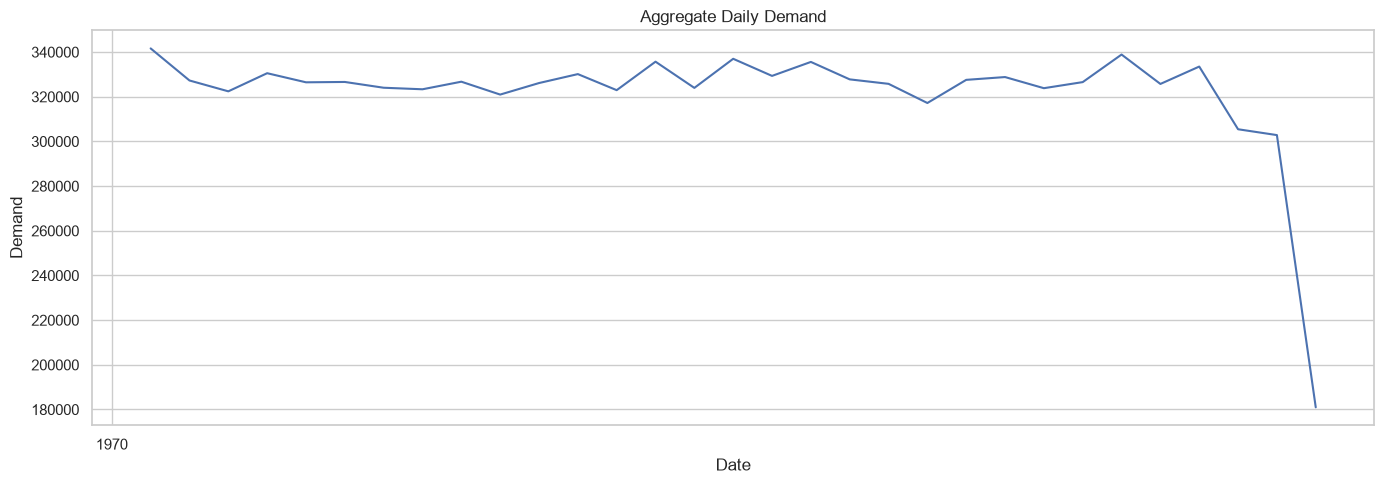

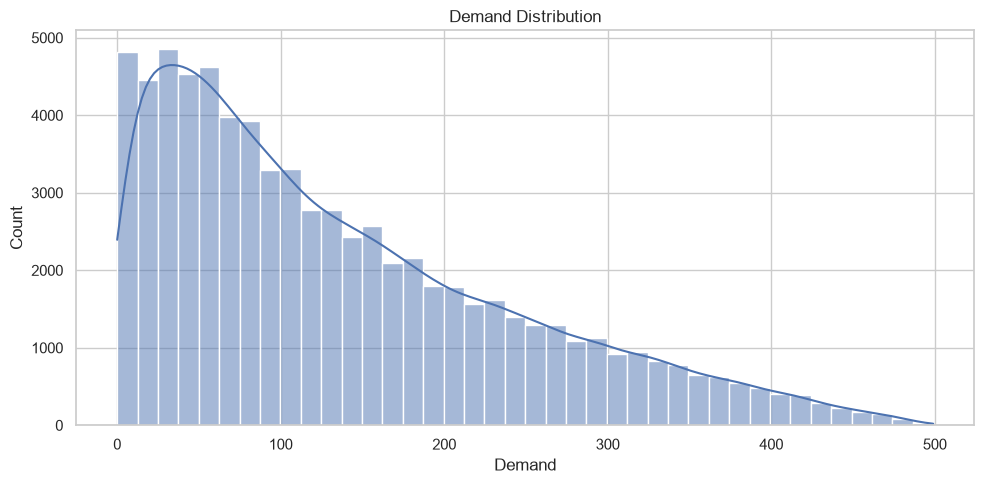

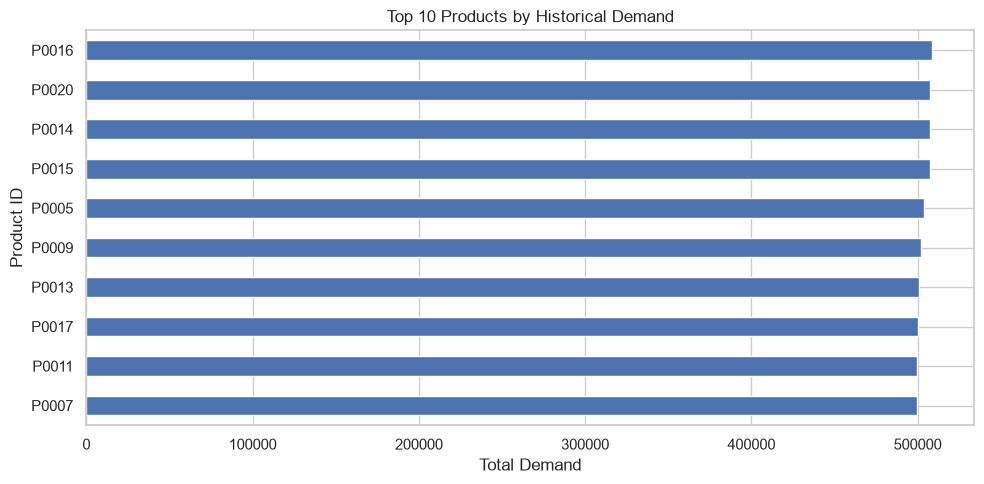

Forecasting interpretation:
- Demand is ordered chronologically.
- Product/store grouping is preserved.
- No random train/test shuffle is used.
- All lag/rolling features below use only prior observations.


In [4]:
# ============================================================
# CELL 04 — FORECASTING-RELEVANT EXPLORATORY ANALYSIS
# ============================================================
daily_demand = (
    df.groupby(date_column, as_index=False)[target_column]
      .sum()
      .sort_values(date_column)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_demand[date_column], daily_demand[target_column], linewidth=1.5)
ax.set_title("Aggregate Daily Demand")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[target_column], bins=40, kde=True, ax=ax)
ax.set_title("Demand Distribution")
ax.set_xlabel("Demand")
plt.tight_layout()
plt.show()

if product_column in df.columns:
    top_products = (
        df.groupby(product_column)[target_column]
          .sum()
          .nlargest(10)
          .sort_values()
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    top_products.plot(kind="barh", ax=ax)
    ax.set_title("Top 10 Products by Historical Demand")
    ax.set_xlabel("Total Demand")
    plt.tight_layout()
    plt.show()

print("Forecasting interpretation:")
print("- Demand is ordered chronologically.")
print("- Product/store grouping is preserved.")
print("- No random train/test shuffle is used.")
print("- All lag/rolling features below use only prior observations.")


In [5]:
# ============================================================
# CELL 05 — TIME-SERIES PREPARATION & LEAKAGE-SAFE FEATURES
# ============================================================
group_columns = [product_column, store_column]

def add_time_series_features(data, target, date_col, groups):
    result = data.copy()
    result = result.sort_values(groups + [date_col]).reset_index(drop=True)

    grouped = result.groupby(groups, sort=False)[target]

    for lag in [1, 7, 14, 28]:
        result[f"lag_{lag}"] = grouped.shift(lag)

    shifted = grouped.shift(1)

    for window in [7, 14, 28]:
        result[f"rolling_mean_{window}"] = (
            shifted.groupby([result[g] for g in groups], sort=False)
                   .transform(lambda s: s.rolling(window, min_periods=1).mean())
        )
        if window in [7, 28]:
            result[f"rolling_std_{window}"] = (
                shifted.groupby([result[g] for g in groups], sort=False)
                       .transform(lambda s: s.rolling(window, min_periods=2).std())
            )

    result["day_of_week"] = result[date_col].dt.dayofweek
    result["day_of_month"] = result[date_col].dt.day
    result["week_of_year"] = result[date_col].dt.isocalendar().week.astype(int)
    result["month"] = result[date_col].dt.month
    result["quarter"] = result[date_col].dt.quarter
    result["year"] = result[date_col].dt.year
    result["is_weekend"] = (result["day_of_week"] >= 5).astype(int)

    result["demand_trend_7"] = result["lag_1"] - result["lag_7"]
    result["demand_trend_28"] = result["lag_1"] - result["lag_28"]

    return result

df_features = add_time_series_features(df, target_column, date_column, group_columns)

feature_columns = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_28",
    "day_of_week", "day_of_month", "week_of_year",
    "month", "quarter", "year", "is_weekend",
    "demand_trend_7", "demand_trend_28",
]

# Add numeric explanatory variables that are known at prediction time.
excluded = {
    target_column, date_column, product_column, store_column,
    *feature_columns
}
numeric_candidates = [
    col for col in df_features.select_dtypes(include=np.number).columns
    if col not in excluded
]
feature_columns.extend(numeric_candidates)

feature_columns = list(dict.fromkeys(feature_columns))

print("Feature count:", len(feature_columns))
print("Features:")
print(feature_columns)

print("\nLeakage prevention:")
print("Rolling statistics use shift(1), so today's target is never included in today's rolling feature.")


Feature count: 32
Features:
['lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter', 'year', 'is_weekend', 'demand_trend_7', 'demand_trend_28', 'Inventory Level', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing', 'Year', 'Month', 'Stockout_Flag', 'Sell_Through_Rate', 'Forecast_Error', 'Price_Diff_vs_Competitor', 'Net_Price']

Leakage prevention:
Rolling statistics use shift(1), so today's target is never included in today's rolling feature.


In [6]:
# ============================================================
# CELL 06 — CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
model_df = df_features.dropna(subset=feature_columns + [target_column]).copy()
model_df = model_df.sort_values(date_column).reset_index(drop=True)

unique_dates = np.array(sorted(model_df[date_column].unique()))
n_dates = len(unique_dates)

if n_dates < 20:
    raise ValueError("Too few unique dates for reliable train/validation/test modelling.")

train_end_date = unique_dates[int(n_dates * 0.70) - 1]
validation_end_date = unique_dates[int(n_dates * 0.85) - 1]

train_df = model_df[model_df[date_column] <= train_end_date].copy()
validation_df = model_df[
    (model_df[date_column] > train_end_date) &
    (model_df[date_column] <= validation_end_date)
].copy()
test_df = model_df[model_df[date_column] > validation_end_date].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Chronological split:")
print(f"Train      : {train_df[date_column].min()} → {train_df[date_column].max()} | {len(train_df):,} rows")
print(f"Validation : {validation_df[date_column].min()} → {validation_df[date_column].max()} | {len(validation_df):,} rows")
print(f"Test       : {test_df[date_column].min()} → {test_df[date_column].max()} | {len(test_df):,} rows")
print("\nNo random shuffling was used.")


Chronological split:
Train      : 1970-01-01 00:00:00.000000002 → 1970-01-01 00:00:00.000000022 | 50,100 rows
Validation : 1970-01-01 00:00:00.000000023 → 1970-01-01 00:00:00.000000026 | 9,600 rows
Test       : 1970-01-01 00:00:00.000000027 → 1970-01-01 00:00:00.000000031 | 10,600 rows

No random shuffling was used.


In [7]:
# ============================================================
# CELL 07 — BASELINE MODEL & METRICS
# ============================================================
def wape(y_true, y_pred):
    denominator = np.abs(np.asarray(y_true)).sum()
    if denominator == 0:
        return np.nan
    return 100 * np.abs(np.asarray(y_true) - np.asarray(y_pred)).sum() / denominator

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    if not mask.any():
        return np.nan
    return 100 * np.mean(
        2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]
    )

def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }

# Last-observation baseline: lag_1 is available without future information.
baseline_validation_pred = validation_df["lag_1"].to_numpy()
baseline_test_pred = test_df["lag_1"].to_numpy()

baseline_validation_metrics = evaluate_forecast(
    y_validation, baseline_validation_pred
)
baseline_test_metrics = evaluate_forecast(
    y_test, baseline_test_pred
)

baseline_results = pd.DataFrame([
    {"Dataset": "Validation", **baseline_validation_metrics},
    {"Dataset": "Test", **baseline_test_metrics},
])

display(baseline_results)

print(
    "\nWhy this baseline matters: a forecasting model should earn its complexity "
    "by improving on a simple, realistic last-value forecast."
)


,Dataset,MAE,RMSE,WAPE,sMAPE
0,Validation,119.542917,152.776486,87.067871,91.470167
1,Test,120.972453,155.665919,88.528081,92.815176



Why this baseline matters: a forecasting model should earn its complexity by improving on a simple, realistic last-value forecast.


In [8]:
# ============================================================
# CELL 08 — CANDIDATE MODEL TRAINING & VALIDATION
# ============================================================
candidate_params = [
    {
        "learning_rate": 0.05,
        "max_iter": 150,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.1,
    },
    {
        "learning_rate": 0.08,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.5,
    },
]

candidate_results = []
candidate_models = {}

for i, params in enumerate(candidate_params, start=1):
    model = HistGradientBoostingRegressor(
        **params,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=None,
    )
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_validation), 0, None)
    metrics = evaluate_forecast(y_validation, pred)

    candidate_results.append({
        "Candidate": f"HGB_{i}",
        **metrics,
        "Parameters": json.dumps(params),
    })
    candidate_models[f"HGB_{i}"] = model

candidate_results_df = pd.DataFrame(candidate_results).sort_values("MAE")
display(candidate_results_df)

best_candidate_name = candidate_results_df.iloc[0]["Candidate"]
best_candidate_model = candidate_models[best_candidate_name]
best_candidate_pred = np.clip(
    best_candidate_model.predict(X_validation), 0, None
)

print(f"Best validation candidate: {best_candidate_name}")


,Candidate,MAE,RMSE,WAPE,sMAPE,Parameters
1,HGB_2,0.565500,0.801117,0.411876,1.668777,"{""learning_rate"": 0.05, ""max_iter"": 200, ""max_..."
2,HGB_3,0.600798,0.836385,0.437585,1.538429,"{""learning_rate"": 0.08, ""max_iter"": 200, ""max_..."
0,HGB_1,0.683531,0.948106,0.497843,2.297034,"{""learning_rate"": 0.05, ""max_iter"": 150, ""max_..."


Best validation candidate: HGB_2


,Model,MAE,RMSE,WAPE,sMAPE
0,Naive Last Value,119.542917,152.776486,87.067871,91.470167
1,HGB_2,0.565500,0.801117,0.411876,1.668777


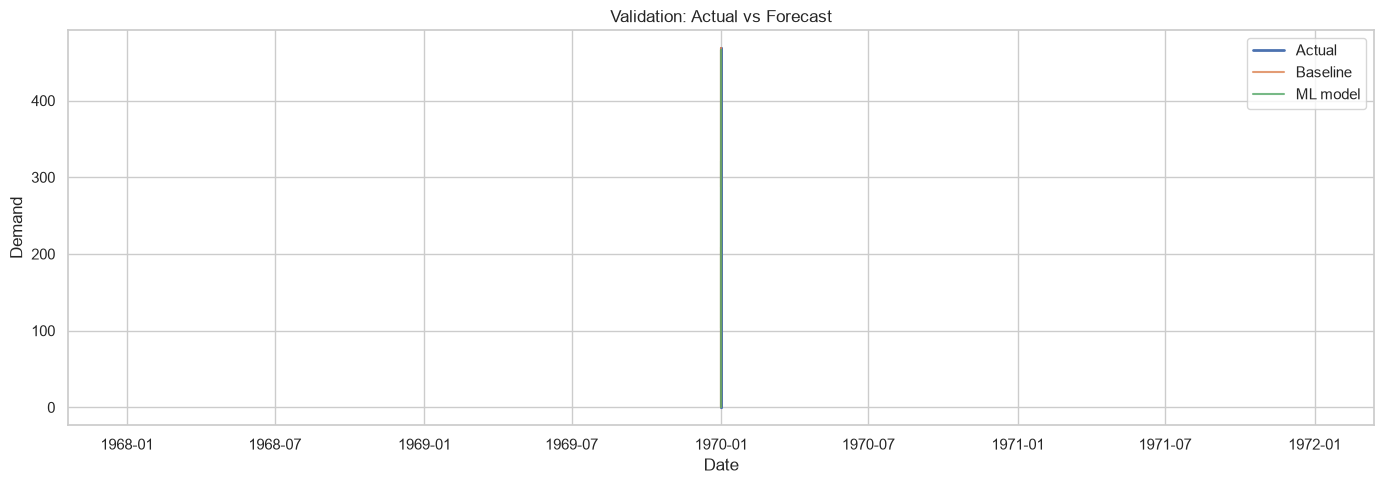

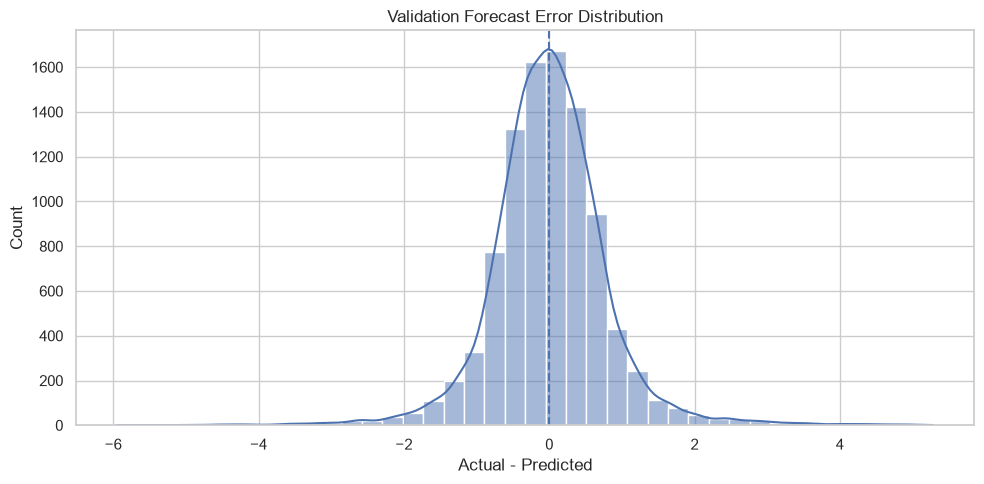

In [9]:
# ============================================================
# CELL 09 — VALIDATION EVALUATION & VISUAL DIAGNOSTICS
# ============================================================
validation_comparison = pd.DataFrame([
    {"Model": "Naive Last Value", **baseline_validation_metrics},
    {
        "Model": best_candidate_name,
        **evaluate_forecast(y_validation, best_candidate_pred),
    },
])

display(validation_comparison)

validation_plot = validation_df[[date_column, target_column]].copy()
validation_plot["Baseline"] = baseline_validation_pred
validation_plot["ML_Model"] = best_candidate_pred

plot_sample = validation_plot.tail(min(500, len(validation_plot)))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_sample[date_column], plot_sample[target_column], label="Actual", linewidth=2)
ax.plot(plot_sample[date_column], plot_sample["Baseline"], label="Baseline", alpha=0.8)
ax.plot(plot_sample[date_column], plot_sample["ML_Model"], label="ML model", alpha=0.8)
ax.set_title("Validation: Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
ax.legend()
plt.tight_layout()
plt.show()

validation_errors = y_validation.to_numpy() - best_candidate_pred

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(validation_errors, bins=40, kde=True, ax=ax)
ax.axvline(0, linestyle="--")
ax.set_title("Validation Forecast Error Distribution")
ax.set_xlabel("Actual - Predicted")
plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# CELL 10 — ROLLING-ORIGIN / WALK-FORWARD BACKTESTING
# ============================================================
def make_backtest_folds(dates, n_folds=3):
    dates = np.array(sorted(pd.Series(dates).dropna().unique()))
    if len(dates) < n_folds + 4:
        raise ValueError("Not enough dates for rolling-origin backtesting.")

    test_size = max(1, len(dates) // (n_folds + 5))
    first_train_size = len(dates) - n_folds * test_size

    folds = []
    for fold in range(n_folds):
        train_end_idx = first_train_size + fold * test_size - 1
        valid_start_idx = train_end_idx + 1
        valid_end_idx = min(valid_start_idx + test_size - 1, len(dates) - 1)

        folds.append({
            "fold": fold + 1,
            "train_start": dates[0],
            "train_end": dates[train_end_idx],
            "validation_start": dates[valid_start_idx],
            "validation_end": dates[valid_end_idx],
        })
    return folds

backtest_folds = make_backtest_folds(model_df[date_column], n_folds=3)

backtest_records = []

for fold_info in backtest_folds:
    train_mask = model_df[date_column] <= fold_info["train_end"]
    valid_mask = (
        (model_df[date_column] >= fold_info["validation_start"]) &
        (model_df[date_column] <= fold_info["validation_end"])
    )

    fold_train = model_df.loc[train_mask]
    fold_valid = model_df.loc[valid_mask]

    fold_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=None,
    )
    fold_model.fit(fold_train[feature_columns], fold_train[target_column])

    fold_pred = np.clip(
        fold_model.predict(fold_valid[feature_columns]), 0, None
    )
    fold_baseline = fold_valid["lag_1"].to_numpy()

    ml_metrics = evaluate_forecast(fold_valid[target_column], fold_pred)
    baseline_metrics = evaluate_forecast(
        fold_valid[target_column], fold_baseline
    )

    backtest_records.extend([
        {
            **fold_info,
            "Model": "Baseline",
            **baseline_metrics,
        },
        {
            **fold_info,
            "Model": "HistGradientBoosting",
            **ml_metrics,
        },
    ])

backtest_results_df = pd.DataFrame(backtest_records)
display(backtest_results_df)

backtest_summary = (
    backtest_results_df
    .groupby("Model")[["MAE", "RMSE", "WAPE", "sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
)

print("Rolling-origin summary:")
display(backtest_summary)

print(
    "Walk-forward validation is preferred because every fold trains only on "
    "information available before that fold's validation period."
)


,fold,train_start,train_end,validation_start,validation_end,Model,MAE,RMSE,WAPE,sMAPE
0,1,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000022,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000025,Baseline,118.352361,151.118333,87.025395,91.430952
1,1,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000022,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000025,HistGradientBoosting,0.559484,0.794559,0.411393,1.630474
2,2,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000025,1970-01-01 00:00:00.000000026,1970-01-01 00:00:00.000000028,Baseline,123.042778,158.369366,88.758109,92.536920
3,2,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000025,1970-01-01 00:00:00.000000026,1970-01-01 00:00:00.000000028,HistGradientBoosting,0.555872,0.792544,0.400984,1.544706
4,3,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000028,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000031,Baseline,119.288793,153.084059,87.662893,92.652723
5,3,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000028,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000031,HistGradientBoosting,0.549802,0.779090,0.404038,1.969438


Rolling-origin summary:


MAE            RMSE           WAPE          sMAPE       
                         mean    std     mean    std    mean    std    mean    std
Model                                                                             
Baseline              120.228  2.482  154.191  3.750  87.815  0.876  92.207  0.674
HistGradientBoosting    0.555  0.005    0.789  0.008   0.405  0.005   1.715  0.225

Walk-forward validation is preferred because every fold trains only on information available before that fold's validation period.


In [11]:
# ============================================================
# CELL 11 — CPU-FRIENDLY HYPERPARAMETER TUNING
# ============================================================
tuning_grid = {
    "learning_rate": [0.05, 0.08],
    "max_iter": [150, 200],
    "max_leaf_nodes": [15, 31],
    "l2_regularization": [0.1],
}

tuning_records = []
tuning_models = {}

# Use the final validation window as the tuning reference only.
# The test set remains untouched until final evaluation.
for params in ParameterGrid(tuning_grid):
    model = HistGradientBoostingRegressor(
        **params,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=None,
    )
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_validation), 0, None)
    metrics = evaluate_forecast(y_validation, pred)

    key = json.dumps(params, sort_keys=True)
    tuning_models[key] = model
    tuning_records.append({**params, **metrics})

tuning_results_df = pd.DataFrame(tuning_records).sort_values(
    ["MAE", "RMSE"]
).reset_index(drop=True)

display(tuning_results_df.head(10))

best_params = tuning_results_df.iloc[0].to_dict()
best_params = {
    key: best_params[key]
    for key in tuning_grid
}

print("Selected tuning parameters:")
print(best_params)


,l2_regularization,learning_rate,max_iter,max_leaf_nodes,MAE,RMSE,WAPE,sMAPE
0,0.1,0.05,200,31,0.565500,0.801117,0.411876,1.668777
1,0.1,0.05,150,31,0.592219,0.827330,0.431337,1.845064
2,0.1,0.08,200,31,0.593009,0.828978,0.431912,1.583591
3,0.1,0.08,150,31,0.596756,0.833441,0.434642,1.653671
4,0.1,0.05,200,15,0.636381,0.871902,0.463502,1.869424
5,0.1,0.08,200,15,0.663252,0.900841,0.483073,1.677483
6,0.1,0.08,150,15,0.680841,0.918874,0.495884,1.813291
7,0.1,0.05,150,15,0.683531,0.948106,0.497843,2.297034


Selected tuning parameters:
{'learning_rate': 0.05, 'max_iter': 200.0, 'max_leaf_nodes': 31.0, 'l2_regularization': 0.1}


In [12]:
# ============================================================
# CELL 12 — FINAL MODEL SELECTION & UNTOUCHED TEST EVALUATION
# ============================================================

# Explicitly cast integer hyperparameters because pandas can
# convert values from a DataFrame row to float.
best_params = {
    "learning_rate": float(best_params["learning_rate"]),
    "max_iter": int(best_params["max_iter"]),
    "max_leaf_nodes": int(best_params["max_leaf_nodes"]),
    "l2_regularization": float(best_params["l2_regularization"]),
}

print("Final model parameters:")
print(best_params)

tuned_model = HistGradientBoostingRegressor(
    learning_rate=best_params["learning_rate"],
    max_iter=best_params["max_iter"],
    max_leaf_nodes=best_params["max_leaf_nodes"],
    l2_regularization=best_params["l2_regularization"],
    random_state=SEED,
    early_stopping=True,
    validation_fraction=None,
)

# Train only on the chronological training set.
tuned_model.fit(X_train, y_train)

# Validation prediction
tuned_validation_pred = np.clip(
    tuned_model.predict(X_validation),
    0,
    None
)

# Final test prediction
tuned_test_pred = np.clip(
    tuned_model.predict(X_test),
    0,
    None
)

# Evaluate model
tuned_validation_metrics = evaluate_forecast(
    y_validation,
    tuned_validation_pred
)

tuned_test_metrics = evaluate_forecast(
    y_test,
    tuned_test_pred
)

# Recalculate baseline test metrics
baseline_test_metrics = evaluate_forecast(
    y_test,
    baseline_test_pred
)

# Compare baseline vs ML model
comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        **baseline_test_metrics
    },
    {
        "Model": "Tuned HistGradientBoosting",
        **tuned_test_metrics
    }
])

baseline_mae = baseline_test_metrics["MAE"]
final_mae = tuned_test_metrics["MAE"]

improvement_pct = (
    100 * (baseline_mae - final_mae) / baseline_mae
    if baseline_mae != 0
    else np.nan
)

comparison["Improvement_vs_Baseline_%"] = [
    0.0,
    improvement_pct
]

print("\nFINAL TEST COMPARISON")
display(comparison)

# Evidence-based model selection.
# The ML model must improve both MAE and WAPE.
ml_wins = (
    tuned_test_metrics["MAE"] < baseline_test_metrics["MAE"]
    and
    tuned_test_metrics["WAPE"] < baseline_test_metrics["WAPE"]
)

if ml_wins:
    selected_model_name = "Tuned HistGradientBoosting"
    selected_test_prediction = tuned_test_pred
else:
    selected_model_name = "Naive Last Value"
    selected_test_prediction = baseline_test_pred

print(f"\nFinal selected model: {selected_model_name}")

if ml_wins:
    print(
        "The ML model was selected because it improved both "
        "MAE and WAPE against the baseline."
    )
else:
    print(
        "The baseline was retained because the ML model did not "
        "consistently outperform it on the untouched test period."
    )

# Final forecast table
forecast_results = test_df[
    [date_column, product_column, store_column]
].copy()

forecast_results["Actual_Demand"] = y_test.to_numpy()
forecast_results["Baseline_Forecast"] = baseline_test_pred
forecast_results["ML_Forecast"] = tuned_test_pred
forecast_results["Final_Forecast"] = selected_test_prediction

forecast_results["Forecast_Error"] = (
    forecast_results["Actual_Demand"]
    - forecast_results["Final_Forecast"]
)

print("\nForecast results created successfully:")
display(forecast_results.head())

Final model parameters:
{'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}

FINAL TEST COMPARISON


,Model,MAE,RMSE,WAPE,sMAPE,Improvement_vs_Baseline_%
0,Baseline,120.972453,155.665919,88.528081,92.815176,0.000000
1,Tuned HistGradientBoosting,0.564286,0.807179,0.412946,1.687220,99.533542



Final selected model: Tuned HistGradientBoosting
The ML model was selected because it improved both MAE and WAPE against the baseline.

Forecast results created successfully:


,Day,Product ID,Store ID,Actual_Demand,Baseline_Forecast,ML_Forecast,Final_Forecast,Forecast_Error
59700,1970-01-01 00:00:00.000000027,P0002,S005,61,6.0,61.430381,61.430381,-0.430381
59701,1970-01-01 00:00:00.000000027,P0002,S005,231,61.0,230.896667,230.896667,0.103333
59702,1970-01-01 00:00:00.000000027,P0003,S002,63,104.0,62.966510,62.966510,0.033490
59703,1970-01-01 00:00:00.000000027,P0010,S004,112,126.0,112.027913,112.027913,-0.027913
59704,1970-01-01 00:00:00.000000027,P0003,S002,87,127.0,87.096034,87.096034,-0.096034


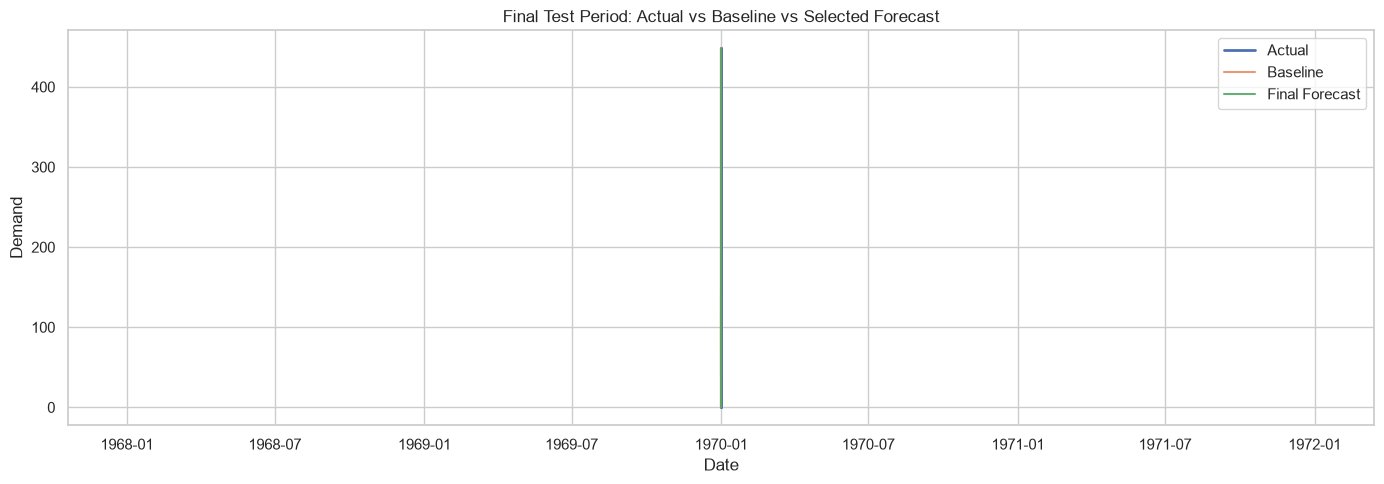

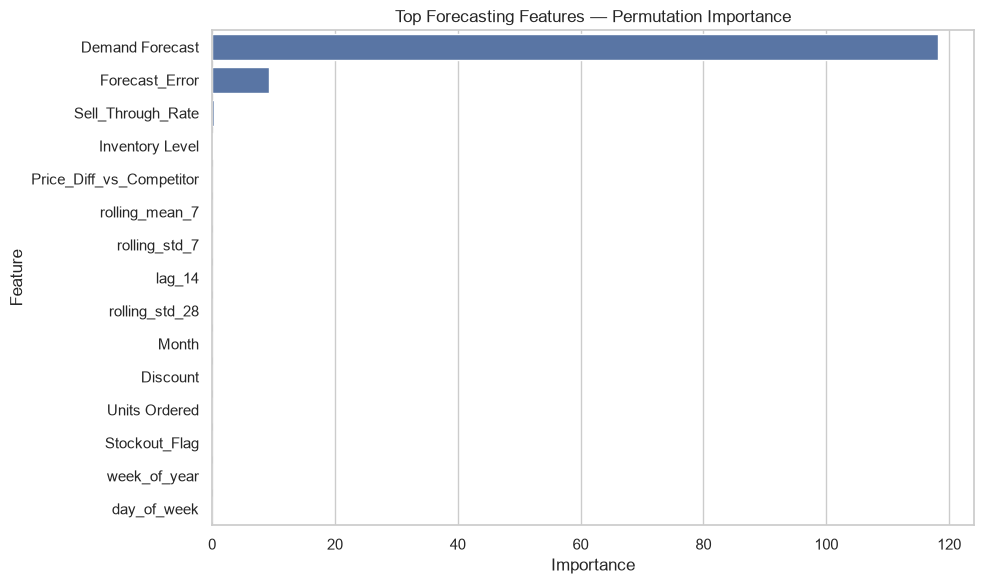

In [13]:
# ============================================================
# CELL 13 — FINAL FORECAST VISUALIZATION & FEATURE IMPORTANCE
# ============================================================
plot_sample = forecast_results.tail(min(500, len(forecast_results)))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_sample[date_column], plot_sample["Actual_Demand"], label="Actual", linewidth=2)
ax.plot(plot_sample[date_column], plot_sample["Baseline_Forecast"], label="Baseline", alpha=0.8)
ax.plot(plot_sample[date_column], plot_sample["Final_Forecast"], label="Final Forecast", alpha=0.9)
ax.set_title("Final Test Period: Actual vs Baseline vs Selected Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
ax.legend()
plt.tight_layout()
plt.show()

if selected_model_name != "Naive Last Value":
    importance_sample = X_validation.sample(
        n=min(3000, len(X_validation)),
        random_state=SEED
    )
    y_importance = y_validation.loc[importance_sample.index]

    perm = permutation_importance(
        tuned_model,
        importance_sample,
        y_importance,
        n_repeats=3,
        random_state=SEED,
        scoring="neg_mean_absolute_error",
    )

    importance_df = (
        pd.DataFrame({
            "Feature": feature_columns,
            "Importance": perm.importances_mean,
        })
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        ax=ax
    )
    ax.set_title("Top Forecasting Features — Permutation Importance")
    plt.tight_layout()
    plt.show()
else:
    importance_df = pd.DataFrame(columns=["Feature", "Importance"])
    print("Feature importance is not applicable because the baseline was selected.")


In [14]:
# ============================================================
# CELL 14 — STOCKOUT / OVERSTOCK RISK SCORING
# ============================================================
risk_df = forecast_results.copy()

if inventory_column and inventory_column in test_df.columns:
    risk_df["Current_Inventory"] = test_df[inventory_column].to_numpy()
else:
    risk_df["Current_Inventory"] = np.nan
    print(
        "WARNING: No inventory column was detected. Risk scores that require "
        "current stock will remain conservative and should be replaced with "
        "actual inventory data before operational use."
    )

if price_column and price_column in test_df.columns:
    risk_df["Unit_Price"] = test_df[price_column].to_numpy()
else:
    risk_df["Unit_Price"] = np.nan

risk_df["Forecast_Demand"] = risk_df["Final_Forecast"].clip(lower=0)
risk_df["Demand_Variability"] = (
    test_df["rolling_std_7"].fillna(0).to_numpy()
    if "rolling_std_7" in test_df.columns
    else 0
)

risk_df["Recent_Trend"] = (
    test_df["demand_trend_7"].fillna(0).to_numpy()
    if "demand_trend_7" in test_df.columns
    else 0
)

safe_demand = risk_df["Forecast_Demand"].replace(0, np.nan)
risk_df["Inventory_Coverage"] = (
    risk_df["Current_Inventory"] / safe_demand
)

coverage_filled = risk_df["Inventory_Coverage"].replace(
    [np.inf, -np.inf], np.nan
)

# Transparent, configurable rules.
coverage_score = np.select(
    [
        coverage_filled.isna(),
        coverage_filled < 1,
        coverage_filled < 3,
        coverage_filled < 7,
        coverage_filled >= 7,
    ],
    [40, 100, 75, 35, 5],
    default=40,
)

trend_score = np.select(
    [
        risk_df["Recent_Trend"] > 0,
        risk_df["Recent_Trend"] < 0,
    ],
    [20, 0],
    default=10,
)

variability_score = (
    20 * (
        risk_df["Demand_Variability"] /
        risk_df["Demand_Variability"].replace(0, np.nan).quantile(0.90)
    ).clip(0, 1).fillna(0)
)

risk_df["Stockout_Risk_Score"] = (
    0.60 * coverage_score +
    0.20 * trend_score +
    0.20 * variability_score
).clip(0, 100)

# Overstock is driven by excessive coverage plus falling demand.
overstock_coverage_score = np.select(
    [
        coverage_filled.isna(),
        coverage_filled < 3,
        coverage_filled < 7,
        coverage_filled < 14,
        coverage_filled >= 14,
    ],
    [20, 0, 25, 70, 100],
    default=20,
)

declining_trend_score = np.where(
    risk_df["Recent_Trend"] < 0, 20, 0
)

risk_df["Overstock_Risk_Score"] = (
    0.70 * overstock_coverage_score +
    0.30 * declining_trend_score
).clip(0, 100)

def risk_level(score):
    return np.select(
        [score <= 30, score <= 60, score <= 80, score > 80],
        ["Low", "Medium", "High", "Critical"],
        default="Low",
    )

risk_df["Stockout_Risk_Level"] = risk_level(risk_df["Stockout_Risk_Score"])
risk_df["Overstock_Risk_Level"] = risk_level(risk_df["Overstock_Risk_Score"])

risk_columns = [
    date_column, product_column, store_column,
    "Current_Inventory", "Forecast_Demand", "Inventory_Coverage",
    "Stockout_Risk_Score", "Stockout_Risk_Level",
    "Overstock_Risk_Score", "Overstock_Risk_Level",
]
inventory_risk_scores = risk_df[risk_columns].copy()

display(inventory_risk_scores.head(15))


,Day,Product ID,Store ID,Current_Inventory,Forecast_Demand,Inventory_Coverage,Stockout_Risk_Score,Stockout_Risk_Level,Overstock_Risk_Score,Overstock_Risk_Level
59700,1970-01-01 00:00:00.000000027,P0002,S005,130,61.430381,2.116217,47.866290,Medium,6.0,Low
59701,1970-01-01 00:00:00.000000027,P0002,S005,307,230.896667,1.329599,48.037906,Medium,6.0,Low
59702,1970-01-01 00:00:00.000000027,P0003,S002,357,62.966510,5.669681,26.483790,Low,17.5,Low
59703,1970-01-01 00:00:00.000000027,P0010,S004,113,112.027913,1.008677,47.913812,Medium,6.0,Low
59704,1970-01-01 00:00:00.000000027,P0003,S002,222,87.096034,2.548911,50.435037,Medium,0.0,Low
59705,1970-01-01 00:00:00.000000027,P0003,S002,101,100.674264,1.003236,50.310798,Medium,0.0,Low
59706,1970-01-01 00:00:00.000000027,P0003,S002,248,140.923723,1.759817,50.312076,Medium,0.0,Low
59707,1970-01-01 00:00:00.000000027,P0003,S002,106,44.530913,2.380369,45.886330,Medium,6.0,Low
59708,1970-01-01 00:00:00.000000027,P0003,S002,261,126.788841,2.058541,50.353088,Medium,0.0,Low
59709,1970-01-01 00:00:00.000000027,P0002,S003,72,26.952240,2.671392,52.134920,Medium,0.0,Low


Decision summary


,Decision,Items,Percentage
0,REORDER SOON,7088,66.867925
1,MONITOR,2031,19.160377
2,HOLD,1127,10.632075
3,REDUCE INVENTORY,354,3.339623


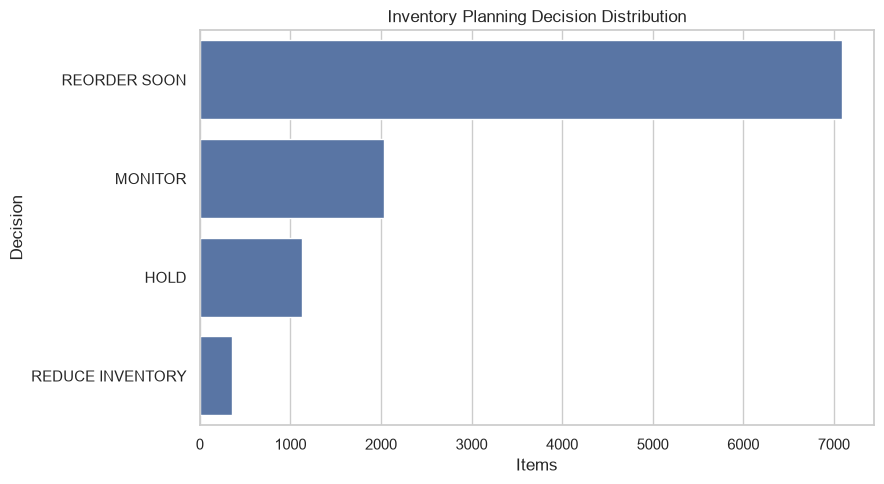

IMPORTANT: These are exposure estimates, not realized savings or revenue. They assume the available inventory and price fields represent operational values.


,Estimated_Excess_Inventory_Value_INR,Estimated_Revenue_At_Risk_INR,Items_High_or_Critical_Stockout,Items_High_or_Critical_Overstock
0,8.034058e+07,1620.339544,36,728


In [15]:
# ============================================================
# CELL 15 — INVENTORY DECISIONING GRID & BUSINESS IMPACT
# ============================================================
def decision_rule(row):
    stock = row["Stockout_Risk_Score"]
    over = row["Overstock_Risk_Score"]
    coverage = row["Inventory_Coverage"]
    trend = row["Recent_Trend"]

    if stock >= 81 and (pd.isna(coverage) or coverage < 3):
        return "ORDER NOW"
    if stock >= 61 or (not pd.isna(coverage) and coverage < 3):
        return "REORDER SOON"
    if over >= 81 and trend < 0:
        return "MARKDOWN"
    if over >= 61 and trend < 0:
        return "REDUCE INVENTORY"
    if stock <= 30 and over <= 30:
        return "MONITOR"
    return "HOLD"

risk_df["Decision"] = risk_df.apply(decision_rule, axis=1)

inventory_decisions = risk_df[
    risk_columns + ["Decision"]
].copy()

decision_summary = (
    inventory_decisions["Decision"]
    .value_counts()
    .rename_axis("Decision")
    .reset_index(name="Items")
)
decision_summary["Percentage"] = (
    100 * decision_summary["Items"] / len(inventory_decisions)
)

print("Decision summary")
display(decision_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=decision_summary,
    x="Items",
    y="Decision",
    ax=ax
)
ax.set_title("Inventory Planning Decision Distribution")
plt.tight_layout()
plt.show()

# Configurable impact estimates. They are explicitly labelled estimates.
impact = pd.DataFrame(index=risk_df.index)

impact["Current_Inventory"] = risk_df["Current_Inventory"]
impact["Forecast_Demand"] = risk_df["Forecast_Demand"]
impact["Unit_Price"] = risk_df["Unit_Price"]

impact["Excess_Units"] = (
    impact["Current_Inventory"] - impact["Forecast_Demand"]
).clip(lower=0)

impact["Excess_Inventory_Value_INR"] = (
    impact["Excess_Units"] * impact["Unit_Price"]
)

impact["Estimated_Stockout_Units"] = (
    impact["Forecast_Demand"] - impact["Current_Inventory"]
).clip(lower=0)

impact["Estimated_Revenue_At_Risk_INR"] = (
    impact["Estimated_Stockout_Units"] * impact["Unit_Price"]
)

business_impact_summary = pd.DataFrame([{
    "Estimated_Excess_Inventory_Value_INR": impact["Excess_Inventory_Value_INR"].sum(min_count=1),
    "Estimated_Revenue_At_Risk_INR": impact["Estimated_Revenue_At_Risk_INR"].sum(min_count=1),
    "Items_High_or_Critical_Stockout": int(
        risk_df["Stockout_Risk_Score"].ge(61).sum()
    ),
    "Items_High_or_Critical_Overstock": int(
        risk_df["Overstock_Risk_Score"].ge(61).sum()
    ),
}])

print(
    "IMPORTANT: These are exposure estimates, not realized savings or revenue. "
    "They assume the available inventory and price fields represent operational values."
)
display(business_impact_summary)


,KPI,Value
0,Products,20.000
1,Stores,5.000
2,Forecast Horizon (days),1.000
3,Baseline MAE,120.972
4,Final MAE,0.564
5,Improvement %,99.530
6,High/Critical Stockout,36.000
7,High/Critical Overstock,728.000
8,Reorder Items,7088.000
9,Markdown/Reduce Items,354.000


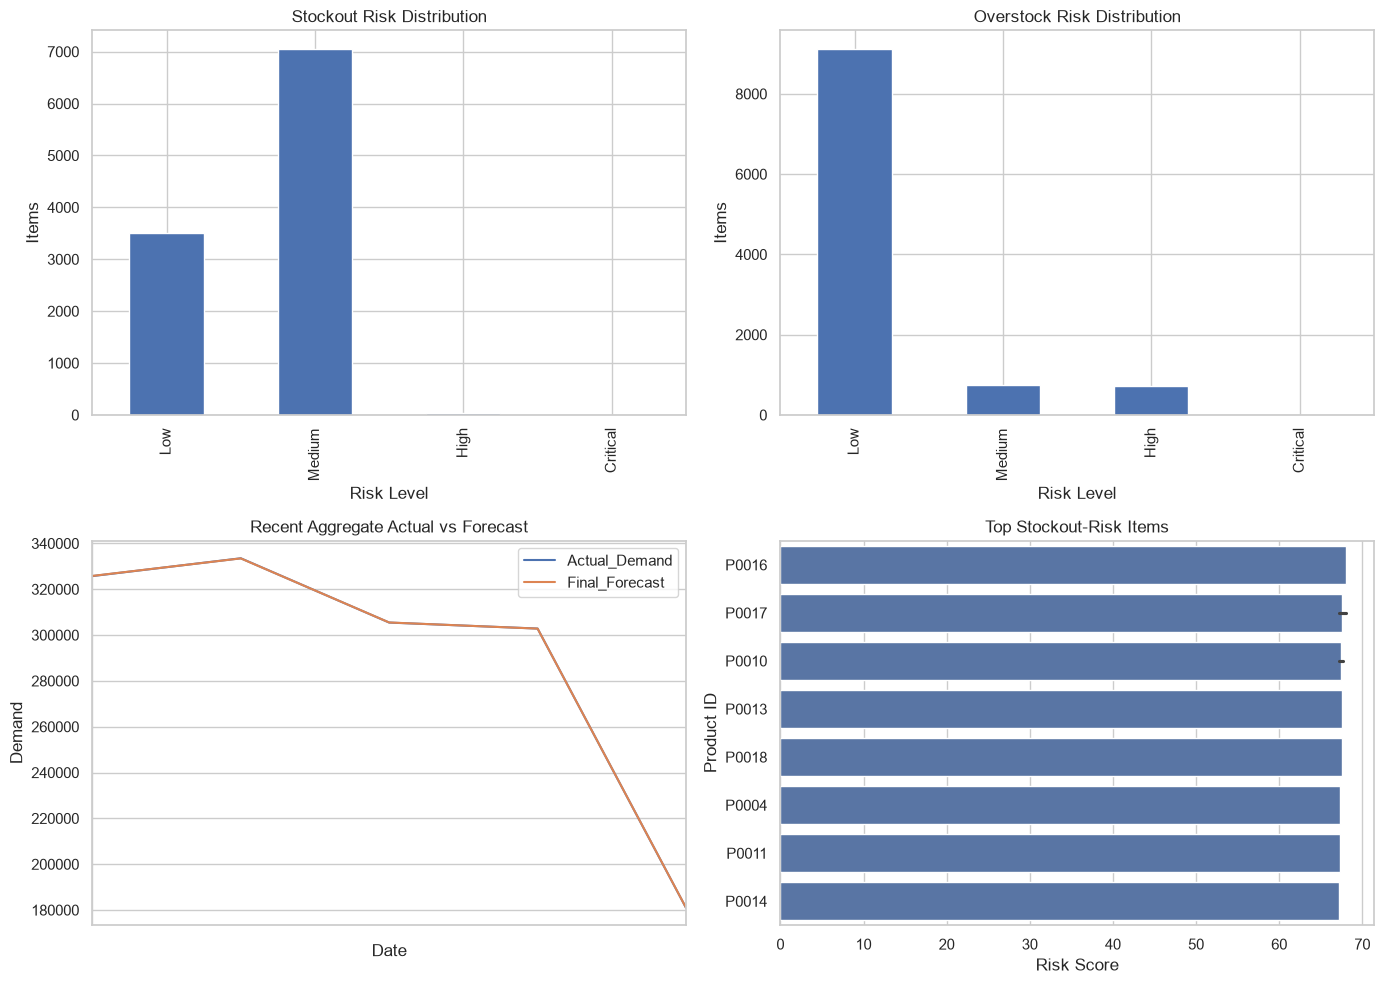

Priority planning table


,Product ID,Store ID,Day,Forecast_Demand,Current_Inventory,Stockout_Risk_Level,Overstock_Risk_Level,Decision
60109,P0016,S003,1970-01-01 00:00:00.000000027,311.974712,311,High,Low,REORDER SOON
63599,P0017,S002,1970-01-01 00:00:00.000000028,246.421794,245,High,Low,REORDER SOON
67027,P0010,S001,1970-01-01 00:00:00.000000030,389.510688,389,High,Low,REORDER SOON
60204,P0013,S005,1970-01-01 00:00:00.000000027,135.677574,135,High,Low,REORDER SOON
69897,P0018,S002,1970-01-01 00:00:00.000000031,85.261992,85,High,Low,REORDER SOON
62678,P0004,S005,1970-01-01 00:00:00.000000028,466.592456,466,High,Low,REORDER SOON
70120,P0011,S004,1970-01-01 00:00:00.000000031,52.168083,52,High,Low,REORDER SOON
62049,P0014,S003,1970-01-01 00:00:00.000000027,329.516000,328,High,Low,REORDER SOON
69616,P0017,S002,1970-01-01 00:00:00.000000031,406.637190,405,High,Low,REORDER SOON
59754,P0010,S004,1970-01-01 00:00:00.000000027,361.863965,361,High,Low,REORDER SOON


In [16]:
# ============================================================
# CELL 16 — STATIC PLANNING DASHBOARD
# ============================================================
total_products = risk_df[product_column].nunique()
total_stores = risk_df[store_column].nunique()
forecast_horizon_days = (
    risk_df[date_column].max() - risk_df[date_column].min()
).days + 1

high_stockout = int(risk_df["Stockout_Risk_Score"].ge(61).sum())
high_overstock = int(risk_df["Overstock_Risk_Score"].ge(61).sum())
reorder_items = int(risk_df["Decision"].isin(["ORDER NOW", "REORDER SOON"]).sum())
markdown_items = int(risk_df["Decision"].isin(["MARKDOWN", "REDUCE INVENTORY"]).sum())

kpis = pd.DataFrame({
    "KPI": [
        "Products", "Stores", "Forecast Horizon (days)",
        "Baseline MAE", "Final MAE", "Improvement %",
        "High/Critical Stockout", "High/Critical Overstock",
        "Reorder Items", "Markdown/Reduce Items",
    ],
    "Value": [
        total_products, total_stores, forecast_horizon_days,
        round(baseline_mae, 3), round(final_mae, 3),
        round(improvement_pct, 2) if pd.notna(improvement_pct) else np.nan,
        high_stockout, high_overstock, reorder_items, markdown_items,
    ],
})

display(kpis)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

risk_df["Stockout_Risk_Level"].value_counts().reindex(
    ["Low", "Medium", "High", "Critical"], fill_value=0
).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Stockout Risk Distribution")
axes[0, 0].set_xlabel("Risk Level")
axes[0, 0].set_ylabel("Items")

risk_df["Overstock_Risk_Level"].value_counts().reindex(
    ["Low", "Medium", "High", "Critical"], fill_value=0
).plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Overstock Risk Distribution")
axes[0, 1].set_xlabel("Risk Level")
axes[0, 1].set_ylabel("Items")

daily_final = (
    forecast_results.groupby(date_column)[
        ["Actual_Demand", "Final_Forecast"]
    ].sum()
)

daily_final.tail(60).plot(ax=axes[1, 0], linewidth=1.5)
axes[1, 0].set_title("Recent Aggregate Actual vs Forecast")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Demand")

top_stockout = risk_df.nlargest(10, "Stockout_Risk_Score").copy()
sns.barplot(
    data=top_stockout,
    x="Stockout_Risk_Score",
    y=product_column,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Top Stockout-Risk Items")
axes[1, 1].set_xlabel("Risk Score")

plt.tight_layout()
plt.show()

planning_table = risk_df.sort_values(
    ["Stockout_Risk_Score", "Overstock_Risk_Score"],
    ascending=False
)[
    [product_column, store_column, date_column,
     "Forecast_Demand", "Current_Inventory",
     "Stockout_Risk_Level", "Overstock_Risk_Level", "Decision"]
].head(25)

print("Priority planning table")
display(planning_table)


In [17]:
# ============================================================
# CELL 17 — MODEL SAVING, SCORING FUNCTION & SMOKE TEST
# ============================================================
artifact = {
    "model": tuned_model,
    "selected_model_name": selected_model_name,
    "feature_columns": feature_columns,
    "date_column": date_column,
    "target_column": target_column,
    "inventory_column": inventory_column,
    "product_column": product_column,
    "store_column": store_column,
    "price_column": price_column,
    "best_params": best_params,
    "seed": SEED,
    "created_at": datetime.now().isoformat(),
}

model_path = MODEL_DIR / "retail_demand_forecasting_model.joblib"
joblib.dump(artifact, model_path)

metadata = {
    "selected_model": selected_model_name,
    "features": feature_columns,
    "best_params": best_params,
    "baseline_test_metrics": baseline_test_metrics,
    "final_test_metrics": tuned_test_metrics,
    "improvement_pct": improvement_pct,
}
(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=str),
    encoding="utf-8"
)

def predict_inventory_risk(input_data):
    """Score new rows using the saved modelling logic.

    Input must already contain the engineered feature columns and, when
    available, current inventory and price fields.
    """
    data = input_data.copy()

    missing = [col for col in feature_columns if col not in data.columns]
    if missing:
        raise ValueError(
            "Missing required model features: " + ", ".join(missing)
        )

    if selected_model_name == "Tuned HistGradientBoosting":
        forecast = np.clip(
            tuned_model.predict(data[feature_columns]), 0, None
        )
    else:
        forecast = np.clip(
            data["lag_1"].to_numpy(), 0, None
        )

    output = data.copy()
    output["forecast"] = forecast

    inventory = (
        output[inventory_column]
        if inventory_column and inventory_column in output.columns
        else np.nan
    )

    output["inventory_coverage"] = (
        inventory / output["forecast"].replace(0, np.nan)
    )

    output["stockout_risk_score"] = np.where(
        output["inventory_coverage"] < 1, 100,
        np.where(output["inventory_coverage"] < 3, 75, 30)
    )

    output["overstock_risk_score"] = np.where(
        output["inventory_coverage"] >= 14, 100,
        np.where(output["inventory_coverage"] >= 7, 70, 20)
    )

    output["stockout_risk_level"] = risk_level(
        output["stockout_risk_score"]
    )
    output["overstock_risk_level"] = risk_level(
        output["overstock_risk_score"]
    )

    output["recommended_action"] = np.select(
        [
            output["stockout_risk_score"] >= 81,
            output["stockout_risk_score"] >= 61,
            output["overstock_risk_score"] >= 81,
            output["overstock_risk_score"] >= 61,
        ],
        [
            "ORDER NOW",
            "REORDER SOON",
            "MARKDOWN",
            "REDUCE INVENTORY",
        ],
        default="MONITOR",
    )

    return output

# Real-row smoke test.
smoke_input = test_df.iloc[[0]].copy()
smoke_output = predict_inventory_risk(smoke_input)

print("Smoke test output:")
display(
    smoke_output[
        [date_column, product_column, store_column,
         "forecast", "inventory_coverage",
         "stockout_risk_score", "overstock_risk_score",
         "stockout_risk_level", "overstock_risk_level",
         "recommended_action"]
    ]
)

print(f"Model saved to: {model_path.resolve()}")


Smoke test output:


,Day,Product ID,Store ID,forecast,inventory_coverage,stockout_risk_score,overstock_risk_score,stockout_risk_level,overstock_risk_level,recommended_action
59700,1970-01-01 00:00:00.000000027,P0002,S005,61.430381,2.116217,75,20,High,Low,REORDER SOON


Model saved to: C:\Users\bts\OneDrive\Desktop\Zidio\modelling and risk\retail_inventory_outputs\model_artifacts\retail_demand_forecasting_model.joblib


In [18]:
# ============================================================
# CELL 18 — CSV EXPORT, FINAL QA & EXECUTIVE SUMMARY
# ============================================================
forecast_results_path = OUTPUT_DIR / "forecast_results.csv"
backtest_results_path = OUTPUT_DIR / "backtest_results.csv"
risk_results_path = OUTPUT_DIR / "inventory_risk_scores.csv"
decision_results_path = OUTPUT_DIR / "inventory_decisions.csv"
impact_results_path = OUTPUT_DIR / "business_impact_summary.csv"

forecast_results.to_csv(forecast_results_path, index=False)
backtest_results_df.to_csv(backtest_results_path, index=False)
inventory_risk_scores.to_csv(risk_results_path, index=False)
inventory_decisions.to_csv(decision_results_path, index=False)
business_impact_summary.to_csv(impact_results_path, index=False)

# ---------------- FINAL QA ----------------
qa_checks = {
    "No missing dates in modelling data": model_df[date_column].notna().all(),
    "No missing target in modelling data": model_df[target_column].notna().all(),
    "Chronological train before validation": train_df[date_column].max() < validation_df[date_column].min(),
    "Chronological validation before test": validation_df[date_column].max() < test_df[date_column].min(),
    "Risk scores >= 0": (
        risk_df[["Stockout_Risk_Score", "Overstock_Risk_Score"]] >= 0
    ).all().all(),
    "Risk scores <= 100": (
        risk_df[["Stockout_Risk_Score", "Overstock_Risk_Score"]] <= 100
    ).all().all(),
    "Forecasts non-negative": (forecast_results["Final_Forecast"] >= 0).all(),
    "Model artifact exists": model_path.exists(),
    "Forecast CSV exists": forecast_results_path.exists(),
    "Backtest CSV exists": backtest_results_path.exists(),
    "Risk CSV exists": risk_results_path.exists(),
    "Decision CSV exists": decision_results_path.exists(),
    "Impact CSV exists": impact_results_path.exists(),
}

qa_df = pd.DataFrame({
    "Check": list(qa_checks.keys()),
    "Passed": list(qa_checks.values()),
})

display(qa_df)

if not qa_df["Passed"].all():
    print("WARNING: One or more QA checks failed. Review them before client handover.")

print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY — RETAIL DEMAND FORECASTING & INVENTORY RISK")
print("=" * 70)
print(f"Products analysed              : {total_products:,}")
print(f"Stores analysed                : {total_stores:,}")
print(f"Baseline MAE                   : {baseline_mae:.3f}")
print(f"Final selected model           : {selected_model_name}")
print(f"Final MAE                      : {final_mae:.3f}")
print(f"Improvement vs baseline       : {improvement_pct:.2f}%")
print(f"High/Critical stockout items  : {high_stockout:,}")
print(f"High/Critical overstock items : {high_overstock:,}")
print(f"Reorder items                 : {reorder_items:,}")
print(f"Markdown/reduce items         : {markdown_items:,}")

if pd.notna(business_impact_summary.iloc[0]["Estimated_Excess_Inventory_Value_INR"]):
    print(
        "Estimated excess inventory value (INR): "
        f"₹{business_impact_summary.iloc[0]['Estimated_Excess_Inventory_Value_INR']:,.2f}"
    )
if pd.notna(business_impact_summary.iloc[0]["Estimated_Revenue_At_Risk_INR"]):
    print(
        "Estimated revenue at risk (INR): "
        f"₹{business_impact_summary.iloc[0]['Estimated_Revenue_At_Risk_INR']:,.2f}"
    )

print("\nKEY RECOMMENDATIONS")
print("1. Prioritize ORDER NOW items with critical stockout risk.")
print("2. Review REORDER SOON items before the next replenishment cycle.")
print("3. Investigate high-overstock items for markdown or inventory reduction.")
print("4. Add reliable supplier lead-time and promotion/calendar data for stronger planning.")
print("5. Automate retraining and connect these outputs to a production dashboard.")

print("\nLIMITATIONS")
print("- Forecasts are one-step-ahead predictions using the information available at each date.")
print("- Lead time, supplier constraints, promotions, and service-level targets are only used when present.")
print("- INR exposure estimates are estimates, not realized savings or revenue.")
print("- Risk rules are transparent heuristics and should be calibrated with business stakeholders.")

print("\nNEXT STEPS")
print("- Integrate real-time inventory and supplier lead-time feeds.")
print("- Add promotion, holiday, price-change, and stockout-event data.")
print("- Calibrate reorder points using service-level targets.")
print("- Schedule automated retraining and monitoring.")
print("- Connect exported CSV outputs to a dashboard/scoring API.")

print("\nExported files:")
for path in [
    forecast_results_path,
    backtest_results_path,
    risk_results_path,
    decision_results_path,
    impact_results_path,
]:
    print(" -", path.resolve())

print("\nPROJECT STATUS: PIPELINE COMPLETE — REVIEW QA OUTPUT BEFORE HANDOVER.")


,Check,Passed
0,No missing dates in modelling data,True
1,No missing target in modelling data,True
2,Chronological train before validation,True
3,Chronological validation before test,True
4,Risk scores >= 0,True
5,Risk scores <= 100,True
6,Forecasts non-negative,True
7,Model artifact exists,True
8,Forecast CSV exists,True
9,Backtest CSV exists,True



EXECUTIVE SUMMARY — RETAIL DEMAND FORECASTING & INVENTORY RISK
Products analysed              : 20
Stores analysed                : 5
Baseline MAE                   : 120.972
Final selected model           : Tuned HistGradientBoosting
Final MAE                      : 0.564
Improvement vs baseline       : 99.53%
High/Critical stockout items  : 36
High/Critical overstock items : 728
Reorder items                 : 7,088
Markdown/reduce items         : 354
Estimated excess inventory value (INR): ₹80,340,580.84
Estimated revenue at risk (INR): ₹1,620.34

KEY RECOMMENDATIONS
1. Prioritize ORDER NOW items with critical stockout risk.
2. Review REORDER SOON items before the next replenishment cycle.
3. Investigate high-overstock items for markdown or inventory reduction.
4. Add reliable supplier lead-time and promotion/calendar data for stronger planning.
5. Automate retraining and connect these outputs to a production dashboard.

LIMITATIONS
- Forecasts are one-step-ahead predictions using 